## Import required libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix

import nltk
import re
import string

from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.tokenize import word_tokenize, sent_tokenize

from tensorflow.keras.preprocessing.text import one_hot, Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Embedding, Input, LSTM, Conv1D, MaxPool1D, Bidirectional
from tensorflow.keras.models import Model

import warnings
warnings.filterwarnings('ignore')

## Download required nltk data


In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

## Mount google drive and read CSV data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

realDf = pd.read_csv('/content/drive/MyDrive/MS-AIML/Data Analytics Capstone/Notebook/dataset/True.csv')
fakeDf = pd.read_csv('/content/drive/MyDrive/MS-AIML/Data Analytics Capstone/Notebook/dataset/Fake.csv')

In [ ]:
realDf.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
fakeDf.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
realDf['label'] = 1
fakeDf['label'] = 0

In [ ]:
df = pd.concat([realDf, fakeDf])
print("Shape of combined dataset = ",df.shape)

Shape of combined dataset =  (44898, 5)


In [ ]:
df["Article"] = df["title"] + df["text"]
df = df.loc[:,["Article","label"]]
df.head()

,Article,label
0,"As U.S. budget fight looms, Republicans flip t...",1
1,U.S. military to accept transgender recruits o...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,1
3,FBI Russia probe helped by Australian diplomat...,1
4,Trump wants Postal Service to charge 'much mor...,1


In [ ]:
print("Shape:", df.shape)
df.head()

Shape: (44898, 2)


,Article,label
0,"As U.S. budget fight looms, Republicans flip t...",1
1,U.S. military to accept transgender recruits o...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,1
3,FBI Russia probe helped by Australian diplomat...,1
4,Trump wants Postal Service to charge 'much mor...,1


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 0 to 23480
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Article  44898 non-null  object
 1   label    44898 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.0+ MB


,0
Article,0
label,0


In [ ]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()
print("Shape:", df.shape)
df.head()

Duplicate rows: 5793
Shape: (39105, 2)


,Article,label
0,"As U.S. budget fight looms, Republicans flip t...",1
1,U.S. military to accept transgender recruits o...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,1
3,FBI Russia probe helped by Australian diplomat...,1
4,Trump wants Postal Service to charge 'much mor...,1


## Data Cleaning

In [ ]:
import re
import string

def clean_text(text, remove_stopwords=False, lemmatize=False, min_word_length=3):
    """
    Clean and preprocess text with optional stopword removal, lemmatization,
    and minimum word length filtering.

    Parameters:
        text (str): Input text
        remove_stopwords (bool): Whether to remove stopwords
        lemmatize (bool): Whether to apply lemmatization
        min_word_length (int): Minimum length of words to keep

    Returns:
        str: Cleaned text
    """

    # Basic cleaning
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'\[.*?\]', '', text)  # Remove bracketed text
    text = re.sub(r'\w*\d\w*', '', text)  # Remove words with numbers
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation/special chars
    text = re.sub(r'\n', ' ', text)  # Replace newline with space
    text = re.sub(r'\s+', ' ', text).strip()  # Normalize whitespace

    words = text.split()

    # Remove short words
    words = [word for word in words if len(word) >= min_word_length]

    # Optional: Stopword removal
    if remove_stopwords:
        try:
            from nltk.corpus import stopwords
            stop_words = set(stopwords.words('english'))
            words = [word for word in words if word not in stop_words]
        except:
            print("NLTK stopwords not found. Run: nltk.download('stopwords')")

    # Optional: Lemmatization
    if lemmatize:
        try:
            from nltk.stem import WordNetLemmatizer
            lemmatizer = WordNetLemmatizer()
            words = [lemmatizer.lemmatize(word) for word in words]
        except:
            print("WordNet not found. Run: nltk.download('wordnet')")

    return " ".join(words)

In [ ]:
df['Article'] = df['Article'].apply(
    lambda x: clean_text(x, remove_stopwords=True, lemmatize=True)
)

In [ ]:
df.head()

,Article,label
0,budget fight loom republican flip fiscal scrip...,1
1,military accept transgender recruit monday pen...,1
2,senior republican senator let mueller jobwashi...,1
3,fbi russia probe helped australian diplomat ti...,1
4,trump want postal service charge much amazon s...,1


## Visualise class distribution

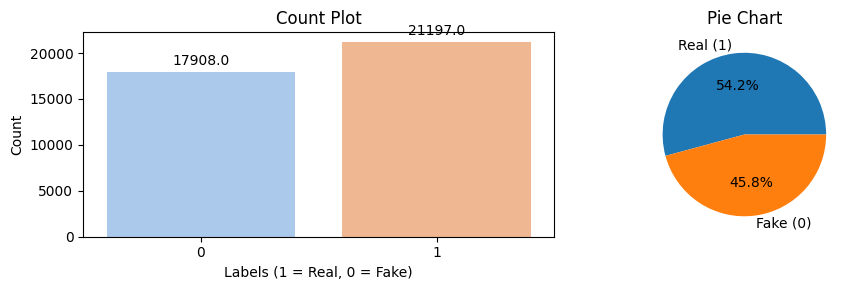

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

sns.countplot(x='label', data=df, palette='pastel', ax=axes[0])

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

axes[0].set_title('Count Plot')
axes[0].set_xlabel('Labels (1 = Real, 0 = Fake)')
axes[0].set_ylabel('Count')


counts = df['label'].value_counts()
labels = [f'Real ({i})' if i == 1 else f'Fake ({i})' for i in counts.index]
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%')
axes[1].set_title('Pie Chart')

plt.tight_layout()

plt.show()

## Top Discriminative Words in Real vs Fake News

In [ ]:
from collections import Counter

def get_top_words(text_series, n=30):
    all_words = " ".join(text_series).split()
    return Counter(all_words).most_common(n)

# Separate classes 1 - Real and 0 - Fake
real_text = df[df['label'] == 1]['Article']
fake_text = df[df['label'] == 0]['Article']


In [ ]:
# Get top words
real_words = get_top_words(real_text.values)
fake_words = get_top_words(fake_text.values)

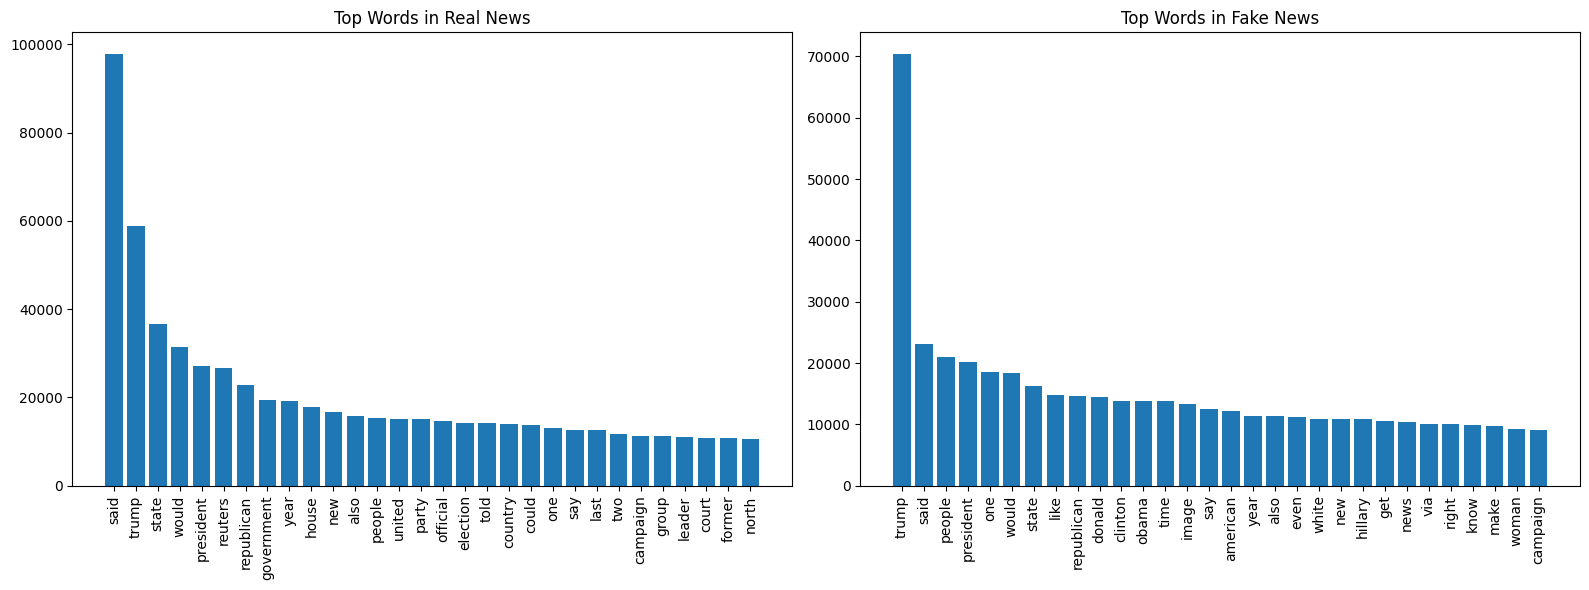

In [ ]:
# Convert to plotting format
real_words_df = dict(real_words)
fake_words_df = dict(fake_words)

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Real News Plot
axes[0].bar(real_words_df.keys(), real_words_df.values())
axes[0].set_title("Top Words in Real News")
axes[0].tick_params(axis='x', rotation=90)

# Fake News Plot
axes[1].bar(fake_words_df.keys(), fake_words_df.values())
axes[1].set_title("Top Words in Fake News")
axes[1].tick_params(axis='x', rotation=90)

# Adjust layout
plt.tight_layout()

# Show combined plot
plt.show()

## Most Frequent Terms Across Real and Fake News Articles

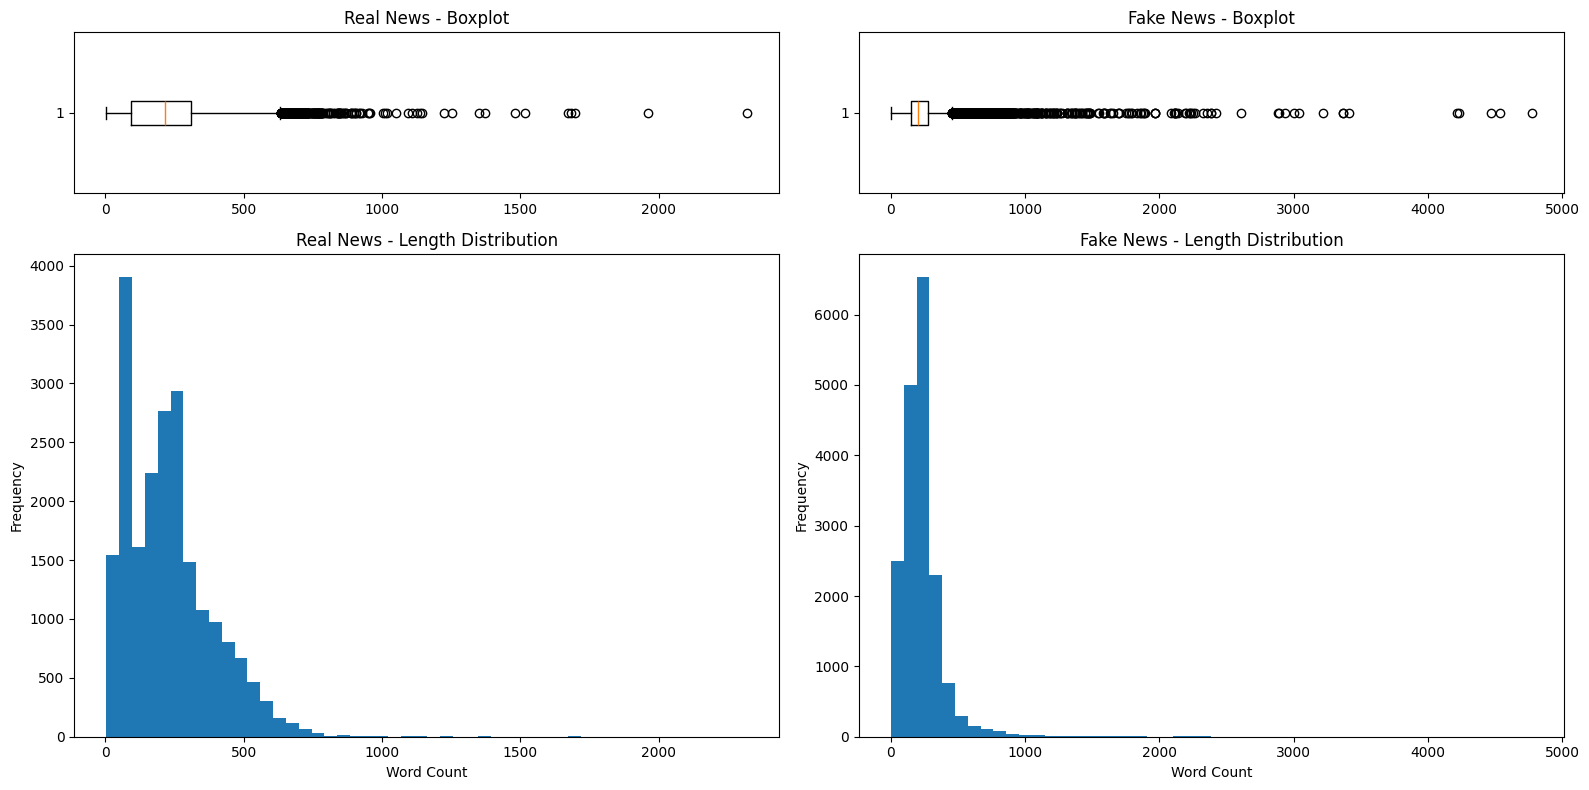

In [ ]:
import matplotlib.pyplot as plt

# Add text length column
df['text_length'] = df['Article'].apply(lambda x: len(x.split()))

# Create 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(16, 8),gridspec_kw={'height_ratios': [1, 3]})

# -------------------
# Real News
# -------------------

# Boxplot (top)
axes[0, 0].boxplot(df[df['label'] == 1]['text_length'], vert=False)
axes[0, 0].set_title("Real News - Boxplot")

# Histogram (bottom)
axes[1, 0].hist(df[df['label'] == 1]['text_length'], bins=50)
axes[1, 0].set_title("Real News - Length Distribution")
axes[1, 0].set_xlabel("Word Count")
axes[1, 0].set_ylabel("Frequency")

# -------------------
# Fake News
# -------------------

# Boxplot (top)
axes[0, 1].boxplot(df[df['label'] == 0]['text_length'], vert=False)
axes[0, 1].set_title("Fake News - Boxplot")

# Histogram (bottom)
axes[1, 1].hist(df[df['label'] == 0]['text_length'], bins=50)
axes[1, 1].set_title("Fake News - Length Distribution")
axes[1, 1].set_xlabel("Word Count")
axes[1, 1].set_ylabel("Frequency")

# Improve spacing
plt.tight_layout()
plt.show()

## WordCloud

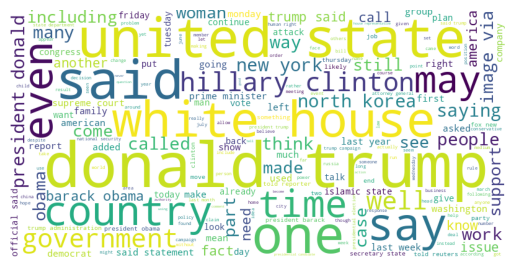

In [ ]:
from wordcloud import WordCloud

text = " ".join(df['Article'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc)
plt.axis('off')
plt.show()

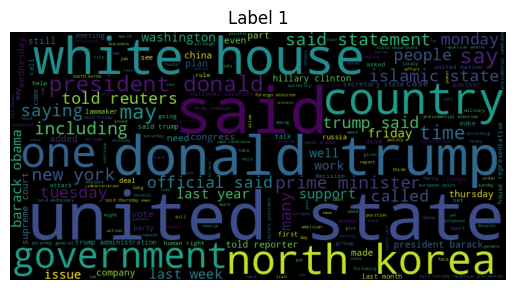

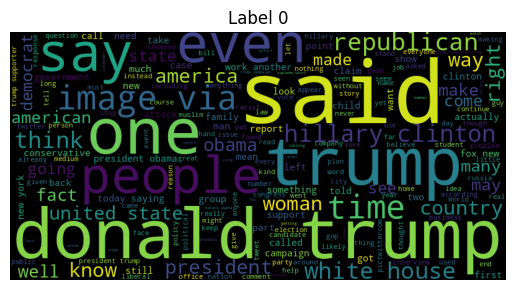

In [ ]:
for label in df['label'].unique():
    text = " ".join(df[df['label'] == label]['Article'])

    wc = WordCloud(width=800, height=400).generate(text)

    plt.imshow(wc)
    plt.axis('off')
    plt.title(f'Label {label}')
    plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(1,2), max_features=20)
X = vectorizer.fit_transform(df['Article'])

print(vectorizer.get_feature_names_out())

['also' 'clinton' 'country' 'donald' 'donald trump' 'government' 'house'
 'new' 'one' 'people' 'president' 'republican' 'reuters' 'said' 'say'
 'state' 'time' 'trump' 'would' 'year']


## Model

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Article'], df['label'], test_size=0.2, random_state=48
)

y_train = np.array(y_train).astype(int)
y_test = np.array(y_test).astype(int)

In [ ]:
max_words = 20000
max_len = 300

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

## RNN model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

rnn_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rnn_history = rnn_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
392/392 ━━━━━━━━━━━━━━━━━━━━ 71s 175ms/step - accuracy: 0.7216 - loss: 0.5203 - val_accuracy: 0.8830 - val_loss: 0.3207
Epoch 2/5
392/392 ━━━━━━━━━━━━━━━━━━━━ 72s 150ms/step - accuracy: 0.8570 - loss: 0.3615 - val_accuracy: 0.5389 - val_loss: 0.7130
Epoch 3/5
392/392 ━━━━━━━━━━━━━━━━━━━━ 65s 165ms/step - accuracy: 0.6210 - loss: 0.5629 - val_accuracy: 0.5822 - val_loss: 0.6160
Epoch 4/5
392/392 ━━━━━━━━━━━━━━━━━━━━ 66s 168ms/step - accuracy: 0.6223 - loss: 0.5540 - val_accuracy: 0.5944 - val_loss: 0.6004
Epoch 5/5
392/392 ━━━━━━━━━━━━━━━━━━━━ 84s 173ms/step - accuracy: 0.6262 - loss: 0.5346 - val_accuracy: 0.5949 - val_loss: 0.6058


## Vanilla LSTM Model

In [ ]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
392/392 ━━━━━━━━━━━━━━━━━━━━ 235s 558ms/step - accuracy: 0.7733 - loss: 0.4240 - val_accuracy: 0.9554 - val_loss: 0.1782
Epoch 2/5
392/392 ━━━━━━━━━━━━━━━━━━━━ 173s 441ms/step - accuracy: 0.9515 - loss: 0.1820 - val_accuracy: 0.9399 - val_loss: 0.2020
Epoch 3/5
392/392 ━━━━━━━━━━━━━━━━━━━━ 163s 416ms/step - accuracy: 0.9548 - loss: 0.1664 - val_accuracy: 0.9516 - val_loss: 0.1824
Epoch 4/5
392/392 ━━━━━━━━━━━━━━━━━━━━ 163s 414ms/step - accuracy: 0.8541 - loss: 0.3365 - val_accuracy: 0.9508 - val_loss: 0.1811
Epoch 5/5
392/392 ━━━━━━━━━━━━━━━━━━━━ 199s 408ms/step - accuracy: 0.9557 - loss: 0.1656 - val_accuracy: 0.9525 - val_loss: 0.1673


## Attention-based LSTM

In [ ]:
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.layers import Attention, GlobalAveragePooling1D
from tensorflow.keras.models import Model

In [ ]:
input_layer = Input(shape=(max_len,))
embedding = Embedding(max_words, 128)(input_layer)

lstm_out = LSTM(64, return_sequences=True)(embedding)

attention = Attention()([lstm_out, lstm_out])
pool = GlobalAveragePooling1D()(attention)

output = Dense(1, activation='sigmoid')(pool)

attention_model = Model(inputs=input_layer, outputs=output)

attention_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

attention_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 300, 128)  │  2,560,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 300, 64)   │     49,408 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 300, 64)   │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,609,473 (9.95 MB)

 Trainable params: 2,609,473 (9.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
att_history = attention_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
392/392 ━━━━━━━━━━━━━━━━━━━━ 266s 670ms/step - accuracy: 0.9247 - loss: 0.2010 - val_accuracy: 0.9767 - val_loss: 0.0816
Epoch 2/5
392/392 ━━━━━━━━━━━━━━━━━━━━ 251s 640ms/step - accuracy: 0.9905 - loss: 0.0466 - val_accuracy: 0.9845 - val_loss: 0.0609
Epoch 3/5
392/392 ━━━━━━━━━━━━━━━━━━━━ 258s 630ms/step - accuracy: 0.9950 - loss: 0.0315 - val_accuracy: 0.9823 - val_loss: 0.0685
Epoch 4/5
392/392 ━━━━━━━━━━━━━━━━━━━━ 262s 631ms/step - accuracy: 0.9983 - loss: 0.0120 - val_accuracy: 0.9795 - val_loss: 0.0822
Epoch 5/5
392/392 ━━━━━━━━━━━━━━━━━━━━ 267s 681ms/step - accuracy: 0.9993 - loss: 0.0052 - val_accuracy: 0.9813 - val_loss: 0.0781


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, X_test, y_test, name):
    y_pred = (model.predict(X_test) > 0.5).astype(int)

    print(f"\n{name} Results")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

In [ ]:
evaluate_model(rnn_model, X_test_pad, y_test, "RNN")
evaluate_model(lstm_model, X_test_pad, y_test, "LSTM")
evaluate_model(attention_model, X_test_pad, y_test, "Attention LSTM")

245/245 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step

RNN Results
Accuracy: 0.6032476665388058
              precision    recall  f1-score   support

           0       0.79      0.15      0.26      3495
           1       0.59      0.97      0.73      4326

    accuracy                           0.60      7821
   macro avg       0.69      0.56      0.49      7821
weighted avg       0.68      0.60      0.52      7821

245/245 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step

LSTM Results
Accuracy: 0.9542258023270681
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      3495
           1       0.94      0.98      0.96      4326

    accuracy                           0.95      7821
   macro avg       0.96      0.95      0.95      7821
weighted avg       0.95      0.95      0.95      7821

245/245 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step

Attention LSTM Results
Accuracy: 0.9832502237565529
              precision    recall  f1-score   support

           0       0.99 

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(title)
    plt.legend()
    plt.show()

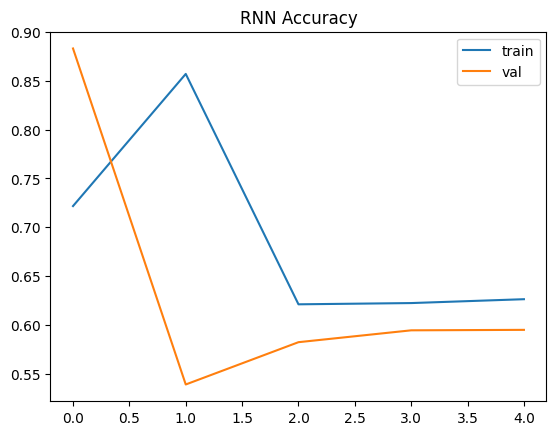

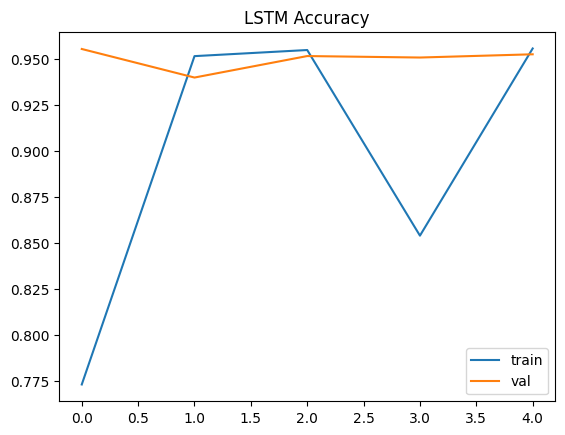

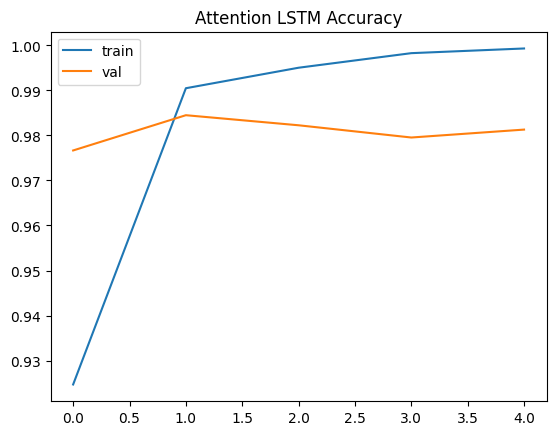

In [ ]:
plot_history(rnn_history, "RNN Accuracy")
plot_history(lstm_history, "LSTM Accuracy")
plot_history(att_history, "Attention LSTM Accuracy")

In [ ]:
results = {}

for name, model in [
    ("RNN", rnn_model),
    ("LSTM", lstm_model),
    ("Attention LSTM", attention_model)
]:
    y_pred = (model.predict(X_test_pad) > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

pd.DataFrame(results.items(), columns=['Model', 'Accuracy'])

245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step
245/245 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step
245/245 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step


,Model,Accuracy
0,RNN,0.603248
1,LSTM,0.954226
2,Attention LSTM,0.983250


## Transformer

In [ ]:
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 32.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Article'], df['label'], test_size=0.2, random_state=48
)

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=512
    )

In [ ]:
from datasets import Dataset

train_df = pd.DataFrame({'text': X_train, 'label': y_train})
test_df = pd.DataFrame({'text': X_test, 'label': y_test})

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

Map:   0%|          | 0/31284 [00:00<?, ? examples/s]

Map:   0%|          | 0/7821 [00:00<?, ? examples/s]

In [ ]:
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def compute_metrics(pred):
    logits, labels = pred
    preds = torch.argmax(torch.tensor(logits), axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [ ]:
import transformers
print(transformers.__version__)

5.0.0


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    eval_strategy="epoch",
    save_strategy="no",
    logging_dir='./logs'
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [ ]:
bert_results = trainer.evaluate()
print(bert_results)

{'eval_loss': 0.6938906908035278, 'eval_model_preparation_time': 0.0048, 'eval_accuracy': 0.5177087328986063, 'eval_f1': 0.5361534677816036, 'eval_precision': 0.5727798213347346, 'eval_recall': 0.5039297272306981, 'eval_runtime': 230.6219, 'eval_samples_per_second': 33.913, 'eval_steps_per_second': 4.241}


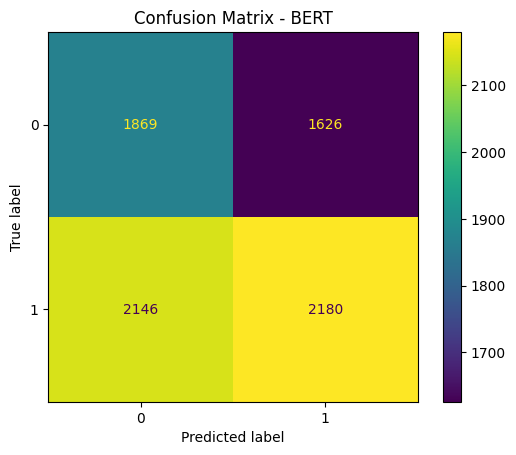

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions = trainer.predict(test_dataset)
y_pred = torch.argmax(torch.tensor(predictions.predictions), axis=1)

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - BERT")
plt.show()

In [ ]:
import numpy as np

y_pred = torch.argmax(torch.tensor(predictions.predictions), axis=1)

print("Predicted labels:", np.unique(y_pred))
print("True labels:", np.unique(y_test))

Predicted labels: [0 1]
True labels: [0 1]


In [ ]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))

label
1    21197
0    17908
Name: count, dtype: int64
label
1    0.542053
0    0.457947
Name: proportion, dtype: float64


In [ ]:
comparison = {
    "RNN": rnn_accuracy,
    "LSTM": lstm_accuracy,
    "Attention LSTM": attention_accuracy,
    "BERT": bert_results['eval_accuracy']
}

pd.DataFrame(comparison.items(), columns=['Model', 'Accuracy'])

## RoBerta

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def tokenize(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=512
    )

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',

    # Core training
    num_train_epochs=4,
    learning_rate=2e-5,

    # Stability
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,

    # Regularization
    weight_decay=0.01,
    warmup_steps=500,

    # Evaluation
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,

    # Logging
    logging_steps=100,
    logging_dir='./logs',

    # Performance
    fp16=True   # use GPU acceleration if available
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

In [ ]:
from transformers import Trainer
from torch.nn import CrossEntropyLoss


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.032726,0.009990,0.998466,0.998613,0.998844,0.998382
2,0.015616,0.010315,0.998594,0.998728,0.999306,0.998151
3,0.017759,0.006235,0.999105,0.999191,0.999537,0.998844
4,0.000121,0.006310,0.999105,0.999191,0.999537,0.998844


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=7824, training_loss=0.07015038092080196, metrics={'train_runtime': 3682.2488, 'train_samples_per_second': 33.984, 'train_steps_per_second': 2.125, 'total_flos': 3.292466502352896e+16, 'train_loss': 0.07015038092080196, 'epoch': 4.0})

In [ ]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.006200396455824375, 'eval_accuracy': 0.9991049737885181, 'eval_f1': 0.9991906578795237, 'eval_precision': 0.9995373583159842, 'eval_recall': 0.9988441978733241, 'eval_runtime': 67.4504, 'eval_samples_per_second': 115.952, 'eval_steps_per_second': 14.5, 'epoch': 4.0}


In [ ]:
predictions = trainer.predict(test_dataset)
y_pred = torch.argmax(torch.tensor(predictions.predictions), axis=1)

import numpy as np
print("Predicted labels:", np.unique(y_pred))

Predicted labels: [0 1]


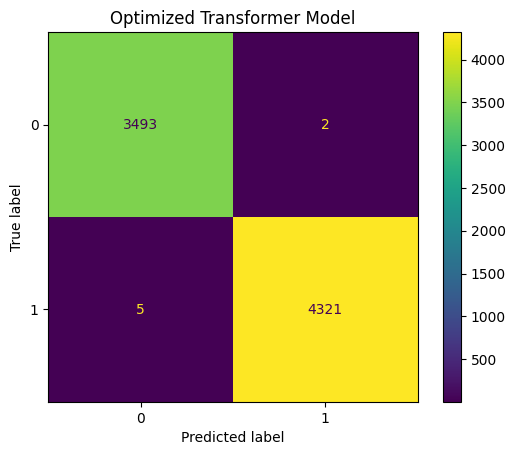

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Optimized Transformer Model")
plt.show()